In [1]:
import sys
sys.path.append("..")
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datasets import load_from_disk
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import shap

from src.data import PROJECT_ROOT
from src.llm_upgrade import wrap_for_transformer_lens
from src.rule_extraction import compute_union_coverage, compute_best_single_rule

In [2]:
EXP_ID = "exp6-1"
MODEL_NAME = "gpt2-large"
VARIANT = "depth-0"
ADAPTER_PATH = str(PROJECT_ROOT / f"results/checkpoints/finetune/{EXP_ID}/checkpoint-11000")
PROBING_JSON = PROJECT_ROOT / "results/probing/probe_gpt2-large(QLoRA)_depth-0_resid_post_last.json"
with open(PROBING_JSON, "r", encoding="utf-8") as f:
    probing_data = json.load(f)
BEST_LAYER = probing_data["summary"]["best_layer"]
SAE_DIR = PROJECT_ROOT / f"results/sae/{EXP_ID}/layer_{BEST_LAYER}"

In [3]:
MAX_SAMPLES_TEST = 2000
N_TRAIN_PREDS = 5000
N_IMPORTANCE_SAMPLES = 500
K_CANDIDATES = [50, 100, 200, 500]
MAX_DEPTH = 3
BATCH_SIZE = 64

In [4]:
BASELINE_DIR = PROJECT_ROOT / "results" / "baselines" / EXP_ID
BASELINE_CACHE_DIR = BASELINE_DIR / "cache"
BASELINE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
torch.cuda.empty_cache()

# Загрузка модели

In [6]:
hooked_model, tokenizer = wrap_for_transformer_lens(MODEL_NAME, ADAPTER_PATH, device="cuda")
hooked_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\peft\tuners\lora\layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Loaded pretrained model gpt2-large into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-35): 36 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_re

# Загрузка датасета и тренировочных активаций

In [7]:
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / f"ruletaker_{VARIANT}"
raw_dataset = load_from_disk(str(DATASET_PATH))

In [8]:
eval_prefix = "{theory} {assertion} The assertion is"
true_ids = tokenizer.encode("True", add_special_tokens=False)
false_ids = tokenizer.encode("False", add_special_tokens=False)
TRUE_ID = true_ids[-1] if true_ids else 0
FALSE_ID = false_ids[-1] if false_ids else 0

In [9]:
def get_prompt_and_len(ex):
    # Форматируем промпт точно как при обучении/оценке
    if "theory" in ex and "assertion" in ex:
        prompt = eval_prefix.format(theory=ex["theory"], assertion=ex["assertion"])
    else:
        prompt = ex["text"]
    # Длина без спецтокенов (для корректного индексирования логитов)
    prompt_len = len(tokenizer.encode(prompt, add_special_tokens=False))
    return prompt, prompt_len

In [10]:
train_acts = torch.load(SAE_DIR / "activations.pt", map_location="cpu", weights_only=False)["activations"]
train_acts = train_acts[:N_TRAIN_PREDS].float().numpy()

# Предсказания LLM на train

In [11]:
train_preds = []
# Исправлено: tqdm теперь знает точное число итераций
with torch.no_grad():
    for i in tqdm(range(0, N_TRAIN_PREDS, BATCH_SIZE), desc="LLM preds (train)"):
        batch_items = [raw_dataset["train"][j] for j in range(i, min(i + BATCH_SIZE, N_TRAIN_PREDS))]
        prompts = []
        prompt_lens = []
        for ex in batch_items:
            p, l = get_prompt_and_len(ex)
            prompts.append(p)
            prompt_lens.append(l)

        tokens = hooked_model.to_tokens(prompts, prepend_bos=True).to("cuda")
        logits = hooked_model(tokens)

        # Перенос на CPU до индексации предотвращает CUDA-sync на каждой итерации
        logits_cpu = logits.cpu()
        for j, seq_len in enumerate(prompt_lens):
            l_true = logits_cpu[j, seq_len, TRUE_ID]
            l_false = logits_cpu[j, seq_len, FALSE_ID]
            train_preds.append(1 if l_true > l_false else 0)

LLM preds (train): 100%|██████████| 79/79 [07:37<00:00,  5.79s/it]


In [12]:
train_preds = np.array(train_preds)
torch.save(torch.from_numpy(train_preds), BASELINE_CACHE_DIR / "train_preds.pt")

In [13]:
train_preds = torch.load(BASELINE_CACHE_DIR / "train_preds.pt", map_location="cpu", weights_only=False).numpy()

# Градиентная важность

In [14]:
d_model = hooked_model.cfg.d_model
neuron_importance = np.zeros(d_model)
HOOK_NAME = f"blocks.{BEST_LAYER}.hook_resid_post"

In [15]:
attr_items = [raw_dataset["train"][i] for i in range(N_IMPORTANCE_SAMPLES)]
attr_prompts = [get_prompt_and_len(ex)[0] for ex in attr_items]
attr_lens = [get_prompt_and_len(ex)[1] for ex in attr_items]

In [16]:
for idx, prompt in enumerate(tqdm(attr_prompts, desc="Gradient attribution")):
    prompt_len = attr_lens[idx]
    tokens = hooked_model.to_tokens([prompt], prepend_bos=True).to("cuda")

    captured_grad = [None]
    def bw_hook(grad, hook):
        captured_grad[0] = grad[0, prompt_len, :].detach().clone()
        return grad

    hooked_model.blocks[BEST_LAYER].hook_resid_post.add_hook(bw_hook, dir="bwd")
    logits = hooked_model(tokens)
    logits[0, prompt_len, TRUE_ID].backward()

    if captured_grad[0] is not None:
        neuron_importance += captured_grad[0].abs().cpu().float().numpy()

    hooked_model.blocks[BEST_LAYER].hook_resid_post.remove_hooks()
    del logits, captured_grad, tokens
    torch.cuda.empty_cache()

Gradient attribution: 100%|██████████| 500/500 [02:36<00:00,  3.19it/s]


In [17]:
neuron_importance /= N_IMPORTANCE_SAMPLES
neuron_importance

array([0.01407043, 0.02603101, 0.00158862, ..., 0.00956036, 0.01094861,
       0.00250804])

In [18]:
torch.save(torch.from_numpy(neuron_importance), BASELINE_CACHE_DIR / "gradient_importance.pt")

In [19]:
neuron_importance = torch.load(BASELINE_CACHE_DIR / "gradient_importance.pt", map_location="cpu", weights_only=False).numpy()

# Тестовые активации и предсказания

In [20]:
test_items = [raw_dataset["test"][i] for i in range(MAX_SAMPLES_TEST)]
test_labels_gt = np.array([int(ex["label"]) for ex in test_items])
test_acts, test_preds = [], []
llm_direct_correct = 0

prompts = []
prompt_lens = []
for ex in test_items:
    p, l = get_prompt_and_len(ex)
    prompts.append(p)
    prompt_lens.append(l)

with torch.no_grad():
    for i in tqdm(range(0, len(prompts), BATCH_SIZE), desc="Test inference & eval"):
        batch_prompts = prompts[i:i+BATCH_SIZE]
        batch_lens = prompt_lens[i:i+BATCH_SIZE]
        tokens = hooked_model.to_tokens(batch_prompts, prepend_bos=True).to("cuda")

        def hook_resid(act, hook):
            for b in range(len(batch_lens)):
                test_acts.append(act[b, batch_lens[b], :].detach().cpu().float().numpy())
            return act

        logits = hooked_model.run_with_hooks(tokens, fwd_hooks=[(HOOK_NAME, hook_resid)])
        logits_cpu = logits.cpu()

        for j, seq_len in enumerate(batch_lens):
            l_true = logits_cpu[j, seq_len, TRUE_ID]
            l_false = logits_cpu[j, seq_len, FALSE_ID]
            pred = 1 if l_true > l_false else 0
            test_preds.append(pred)
            if pred == test_labels_gt[i + j]:
                llm_direct_correct += 1

Test inference & eval: 100%|██████████| 32/32 [05:08<00:00,  9.63s/it]


In [21]:
test_acts = np.array(test_acts)
test_preds = np.array(test_preds)

In [22]:
torch.save({"acts": torch.from_numpy(test_acts), "preds": torch.from_numpy(test_preds)}, BASELINE_CACHE_DIR / "test_acts_preds.pt")

In [23]:
llm_direct_accuracy = llm_direct_correct / MAX_SAMPLES_TEST
with open(BASELINE_CACHE_DIR / "llm_direct_accuracy.json", "w", encoding="utf-8") as f:
    json.dump({"accuracy": float(llm_direct_accuracy)}, f)

In [24]:
test_cache = torch.load(BASELINE_CACHE_DIR / "test_acts_preds.pt", map_location="cpu", weights_only=False)
test_acts = test_cache["acts"].numpy()
test_preds = test_cache["preds"].numpy()

In [25]:
test_items = [raw_dataset["test"][i] for i in range(MAX_SAMPLES_TEST)]
test_labels_gt = np.array([int(ex["label"]) for ex in test_items])

In [26]:
llm_direct_accuracy = float(json.load(open(BASELINE_CACHE_DIR / "llm_direct_accuracy.json", "r"))["accuracy"])
print(f"LLM Direct Accuracy: {llm_direct_accuracy:.4f}")

LLM Direct Accuracy: 0.9990


In [27]:
# Инициализация таблицы результатов
baseline_rows = []

## Обучение DT

In [28]:
for k in K_CANDIDATES:
    top_k = np.argsort(neuron_importance)[::-1][:k]
    dt = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
    dt.fit(train_acts[:, top_k], train_preds)
    dt_preds = dt.predict(test_acts[:, top_k])

    fid = float(np.mean(dt_preds == test_preds))
    acc = float(np.mean(dt_preds == test_labels_gt))
    cov_llm, _ = compute_union_coverage(test_acts, train_acts, test_preds, train_preds, neuron_importance, k)

    baseline_rows.append({
        "Method": "Gradient Importance",
        "Mode": "Decision Tree",
        "K": k,
        "Fidelity_vs_LLM": round(fid, 4),
        "Accuracy_vs_GT": round(acc, 4),
        "Union_Coverage_vs_LLM": round(cov_llm, 4),
        "Notes": "Единая суррогатная модель"
    })
    print(f"GI+DT | K={k:4d} | Fidelity: {fid:.4f} | Accuracy: {acc:.4f} | Union LLM: {cov_llm:.4f}")

GI+DT | K=  50 | Fidelity: 0.9125 | Accuracy: 0.9125 | Union LLM: 1.0000
GI+DT | K= 100 | Fidelity: 0.9830 | Accuracy: 0.9830 | Union LLM: 1.0000
GI+DT | K= 200 | Fidelity: 0.9395 | Accuracy: 0.9405 | Union LLM: 1.0000
GI+DT | K= 500 | Fidelity: 0.6985 | Accuracy: 0.6995 | Union LLM: 1.0000


In [29]:
best_fid_grad, best_rule_grad = compute_best_single_rule(
    test_acts, train_acts, test_preds, train_preds, neuron_importance, top_k_search=500
)

fid = best_rule_grad["feature_id"]
thr = best_rule_grad["threshold"]
preds_gt = (test_acts[:, fid] > thr).astype(int)
if best_rule_grad["corr"] <= 0:
    preds_gt = 1 - preds_gt
acc_grad = float(np.mean(preds_gt == test_labels_gt))

baseline_rows.append({
    "Method": "Gradient Importance",
    "Mode": "Best Single Rule",
    "K": None,
    "Fidelity_vs_LLM": round(best_fid_grad, 4),
    "Accuracy_vs_GT": round(acc_grad, 4),
    "Union_Coverage_vs_LLM": None,
    "Notes": "Одно пороговое правило"
})
print(f"GI+BestSingle | Fidelity: {best_fid_grad:.4f} | Accuracy: {acc_grad:.4f}")

GI+BestSingle | Fidelity: 0.5110 | Accuracy: 0.5100


# SHAP (proxy LR)

In [30]:
proxy = LogisticRegression(max_iter=1000, random_state=42)
proxy.fit(train_acts, train_preds)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
background = shap.sample(train_acts, 100)
explainer = shap.LinearExplainer(proxy, background)

In [32]:
shap_vals = explainer.shap_values(train_acts[:1000])

In [33]:
neuron_importance_shap = np.abs(shap_vals).mean(axis=0)
torch.save(torch.from_numpy(neuron_importance_shap), BASELINE_CACHE_DIR / "shap_importance.pt")

In [34]:
for k in K_CANDIDATES:
    top_k = np.argsort(neuron_importance_shap)[::-1][:k]
    dt = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
    dt.fit(train_acts[:, top_k], train_preds)
    dt_preds = dt.predict(test_acts[:, top_k])

    fid = float(np.mean(dt_preds == test_preds))
    acc = float(np.mean(dt_preds == test_labels_gt))
    cov_llm, _ = compute_union_coverage(test_acts, train_acts, test_preds, train_preds, neuron_importance_shap, k)

    baseline_rows.append({
        "Method": "SHAP (Linear)",
        "Mode": "Decision Tree",
        "K": k,
        "Fidelity_vs_LLM": round(fid, 4),
        "Accuracy_vs_GT": round(acc, 4),
        "Union_Coverage_vs_LLM": round(cov_llm, 4),
        "Notes": "Единая суррогатная модель"
    })
    print(f"SHAP+DT | K={k:4d} | Fidelity: {fid:.4f} | Accuracy: {acc:.4f} | Union LLM: {cov_llm:.4f}")

SHAP+DT | K=  50 | Fidelity: 0.9895 | Accuracy: 0.9885 | Union LLM: 1.0000
SHAP+DT | K= 100 | Fidelity: 0.8625 | Accuracy: 0.8635 | Union LLM: 1.0000
SHAP+DT | K= 200 | Fidelity: 0.9895 | Accuracy: 0.9885 | Union LLM: 1.0000
SHAP+DT | K= 500 | Fidelity: 0.9895 | Accuracy: 0.9885 | Union LLM: 1.0000


In [35]:
best_fid_shap, best_rule_shap = compute_best_single_rule(
    test_acts, train_acts, test_preds, train_preds, neuron_importance_shap, top_k_search=500
)

fid = best_rule_shap["feature_id"]
thr = best_rule_shap["threshold"]
preds_gt = (test_acts[:, fid] > thr).astype(int)
if best_rule_shap["corr"] <= 0:
    preds_gt = 1 - preds_gt
acc_shap = float(np.mean(preds_gt == test_labels_gt))

baseline_rows.append({
    "Method": "SHAP (Linear)",
    "Mode": "Best Single Rule",
    "K": None,
    "Fidelity_vs_LLM": round(best_fid_shap, 4),
    "Accuracy_vs_GT": round(acc_shap, 4),
    "Union_Coverage_vs_LLM": None,
    "Notes": "Одно пороговое правило"
})
print(f"SHAP+BestSingle | Fidelity: {best_fid_shap:.4f} | Accuracy: {acc_shap:.4f}")

SHAP+BestSingle | Fidelity: 0.9605 | Accuracy: 0.9595


# Результаты

In [36]:
df_baseline = pd.DataFrame(baseline_rows)
table_csv_path = BASELINE_DIR / "comparison_table_clean.csv"
table_json_path = BASELINE_DIR / "comparison_table_clean.json"
df_baseline.to_csv(table_csv_path, index=False)
df_baseline.to_json(table_json_path, orient="records", indent=2)
print(df_baseline.to_string(index=False))

             Method             Mode     K  Fidelity_vs_LLM  Accuracy_vs_GT  Union_Coverage_vs_LLM                     Notes
Gradient Importance    Decision Tree  50.0           0.9125          0.9125                    1.0 Единая суррогатная модель
Gradient Importance    Decision Tree 100.0           0.9830          0.9830                    1.0 Единая суррогатная модель
Gradient Importance    Decision Tree 200.0           0.9395          0.9405                    1.0 Единая суррогатная модель
Gradient Importance    Decision Tree 500.0           0.6985          0.6995                    1.0 Единая суррогатная модель
Gradient Importance Best Single Rule   NaN           0.5110          0.5100                    NaN    Одно пороговое правило
      SHAP (Linear)    Decision Tree  50.0           0.9895          0.9885                    1.0 Единая суррогатная модель
      SHAP (Linear)    Decision Tree 100.0           0.8625          0.8635                    1.0 Единая суррогатная модель


In [37]:
dt_results_grad = [r for r in baseline_rows
                   if r["Method"] == "Gradient Importance" and r["Mode"] == "Decision Tree"]
dt_results_shap = [r for r in baseline_rows
                   if r["Method"] == "SHAP (Linear)" and r["Mode"] == "Decision Tree"]

best_single_grad = next((r["Fidelity_vs_LLM"] for r in baseline_rows
                        if r["Method"] == "Gradient Importance" and r["Mode"] == "Best Single Rule"), None)
best_single_shap = next((r["Fidelity_vs_LLM"] for r in baseline_rows
                        if r["Method"] == "SHAP (Linear)" and r["Mode"] == "Best Single Rule"), None)

In [38]:
detailed_results = {
    "experiment_id": EXP_ID,
    "llm_direct_accuracy": round(llm_direct_accuracy, 4),
    "best_single_rule_gradient": round(best_single_grad, 4) if best_single_grad else None,
    "best_single_rule_shap": round(best_single_shap, 4) if best_single_shap else None,
    "dt_results_gradient": dt_results_grad,
    "dt_results_shap": dt_results_shap
}
with open(BASELINE_DIR / "baseline_detailed.json", "w", encoding="utf-8") as f:
    json.dump(detailed_results, f, indent=2, ensure_ascii=False)

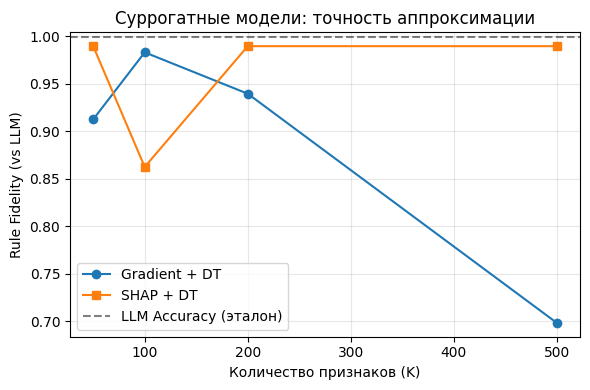

In [39]:
k_vals = K_CANDIDATES
fid_grad = [r["Fidelity_vs_LLM"] for r in baseline_rows
            if r["Method"] == "Gradient Importance" and r["Mode"] == "Decision Tree"]
fid_shap = [r["Fidelity_vs_LLM"] for r in baseline_rows
            if r["Method"] == "SHAP (Linear)" and r["Mode"] == "Decision Tree"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_vals, fid_grad, marker="o", label="Gradient + DT")
ax.plot(k_vals, fid_shap, marker="s", label="SHAP + DT")
ax.axhline(llm_direct_accuracy, color="black", linestyle="--", alpha=0.5, label="LLM Accuracy (эталон)")
ax.set_xlabel("Количество признаков (K)")
ax.set_ylabel("Rule Fidelity (vs LLM)")
ax.set_title("Суррогатные модели: точность аппроксимации")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()